In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals

import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

In [4]:
mnist = tf.keras.datasets.mnist


(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape

(60000, 28, 28)

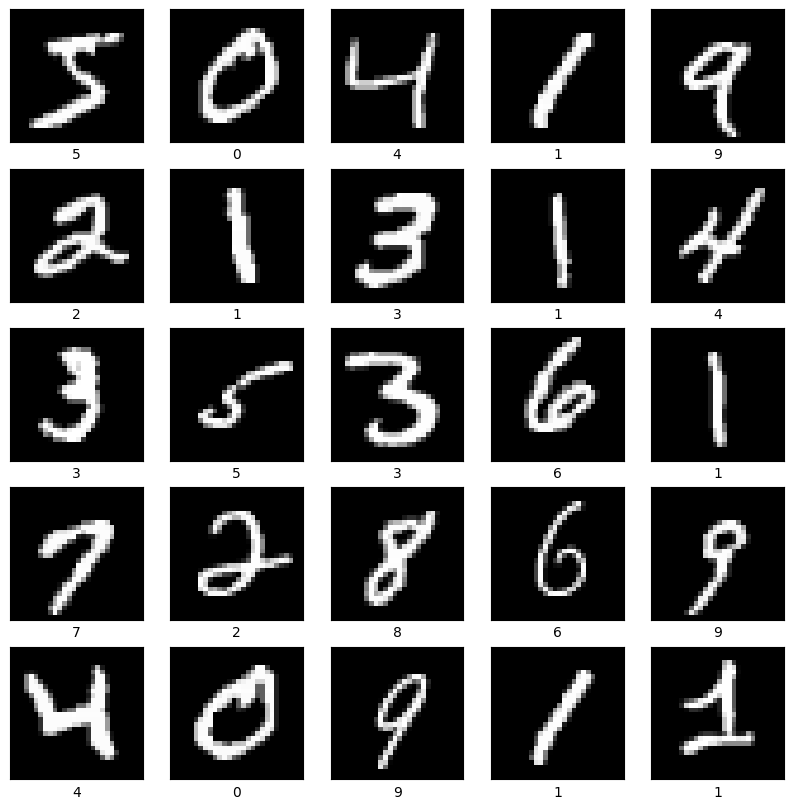

In [5]:
class_names = ['0', '1', '2', '3', '4',
               '5', '6', '7', '8', '9']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow((x_train[i]), cmap ='gray')
    plt.xlabel(class_names[y_train[i]])
plt.show()

In [6]:
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_train.shape
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
x_test.shape

(10000, 28, 28, 1)

In [7]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1))),
model.add(layers.MaxPooling2D((2, 2))),
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2))),
model.add(layers.Conv2D(64, (3, 3), activation='relu')),
model.add(layers.Flatten()),
model.add(layers.Dense(64, activation='relu')),
model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 38ms/step - accuracy: 0.8881 - loss: 0.3577 - val_accuracy: 0.9853 - val_loss: 0.0466
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 39ms/step - accuracy: 0.9836 - loss: 0.0540 - val_accuracy: 0.9873 - val_loss: 0.0400
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 41ms/step - accuracy: 0.9890 - loss: 0.0356 - val_accuracy: 0.9898 - val_loss: 0.0281
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 71s 36ms/step - accuracy: 0.9929 - loss: 0.0251 - val_accuracy: 0.9916 - val_loss: 0.0257
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9929 - loss: 0.0214 - val_accuracy: 0.9893 - val_loss: 0.0353
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9946 - loss: 0.0165 - val_accuracy: 0.9911 - val_loss: 0.0309
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9961 - loss: 0.0119 - val_accuracy: 0.9898 - val_loss: 0.0331
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9968 - loss: 0.01

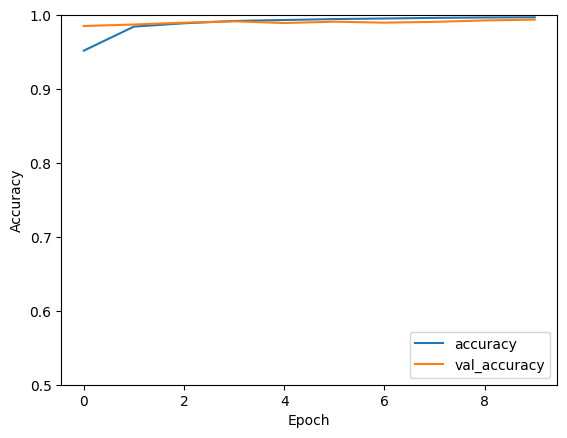

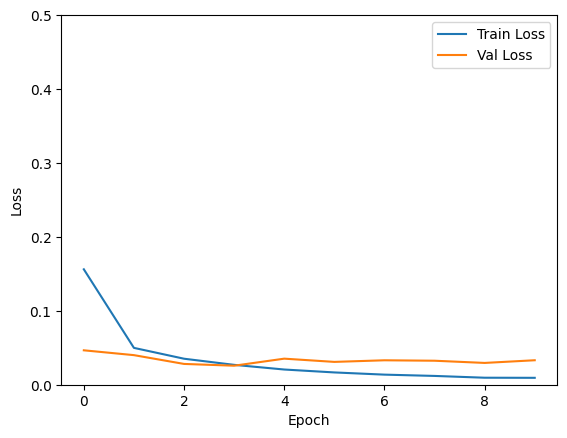

313/313 - 3s - 10ms/step - accuracy: 0.9939 - loss: 0.0331


In [9]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

In [10]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9917 - loss: 0.0427


[0.033105090260505676, 0.9939000010490417]

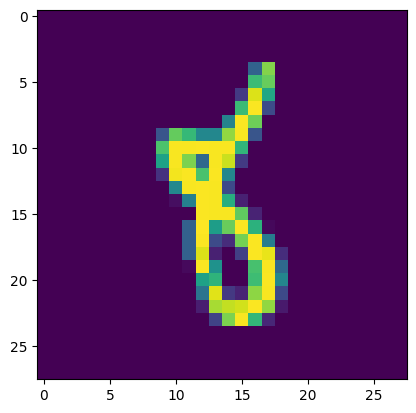

In [11]:
import matplotlib.pyplot as plt
x_test = x_test.reshape(x_test.shape[0], 28, 28)
plt.imshow(x_test[5678])
plt.show()

In [12]:
x_test[5678].shape

(28, 28)

In [13]:
x_test = x_test.reshape(x_test.shape[0], 28, 28,1)
predictions = model.predict(x_test)
print(predictions[5678])
np.argmax(predictions[5678])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
[1.3583144e-12 3.2396070e-08 3.6169628e-10 1.4157318e-06 2.0791457e-12
 1.1816818e-06 9.0897764e-08 2.4487978e-10 9.9999720e-01 6.8194055e-11]


np.int64(8)

In [14]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [15]:
pred=[]
for j in range(len(predictions)):
   pred.append(np.argmax(predictions[j]))

In [16]:
import sklearn
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,pred)

array([[ 977,    1,    0,    0,    0,    0,    0,    2,    0,    0],
       [   0, 1130,    0,    2,    0,    2,    0,    1,    0,    0],
       [   0,    1, 1026,    1,    0,    0,    0,    4,    0,    0],
       [   0,    0,    0, 1006,    0,    2,    0,    2,    0,    0],
       [   0,    0,    0,    0,  975,    0,    3,    0,    0,    4],
       [   0,    0,    0,    4,    0,  886,    1,    0,    0,    1],
       [   2,    2,    1,    0,    1,    5,  947,    0,    0,    0],
       [   0,    4,    0,    0,    0,    0,    0, 1022,    0,    2],
       [   1,    0,    2,    1,    0,    0,    0,    2,  967,    1],
       [   0,    0,    0,    0,    1,    3,    0,    1,    1, 1003]])

In [17]:
from sklearn.metrics import classification_report
print(classification_report(y_test,pred, target_names=class_names))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      1.00      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      1.00       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      1.00       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [18]:
print('Accuracy:', sklearn.metrics.accuracy_score(y_test,pred))

print('F1 score:',sklearn.metrics.f1_score(y_test,pred, average='weighted'))

print( 'Recall:',sklearn.metrics.recall_score(y_test,pred,
                              average='weighted'))

print('Precision:',sklearn.metrics.precision_score(y_test,pred,
                                    average='weighted'))

Accuracy: 0.9939
F1 score: 0.99390258277626
Recall: 0.9939
Precision: 0.9939163661590925


# **Dropout with Early Stopping**

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[early_stopping])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.8005 - loss: 0.7855 - val_accuracy: 0.9833 - val_loss: 0.2062
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 34ms/step - accuracy: 0.9631 - loss: 0.2706 - val_accuracy: 0.9818 - val_loss: 0.1814
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9693 - loss: 0.2311 - val_accuracy: 0.9850 - val_loss: 0.1668
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.9710 - loss: 0.2213 - val_accuracy: 0.9887 - val_loss: 0.1485
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9730 - loss: 0.2041 - val_accuracy: 0.9876 - val_loss: 0.1451
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9741 - loss: 0.1975 - val_accuracy: 0.9893 - val_loss: 0.1413
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9745 - loss: 0.1958 - val_accuracy: 0.9872 - val_loss: 0.1403
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9755 - loss: 0.18

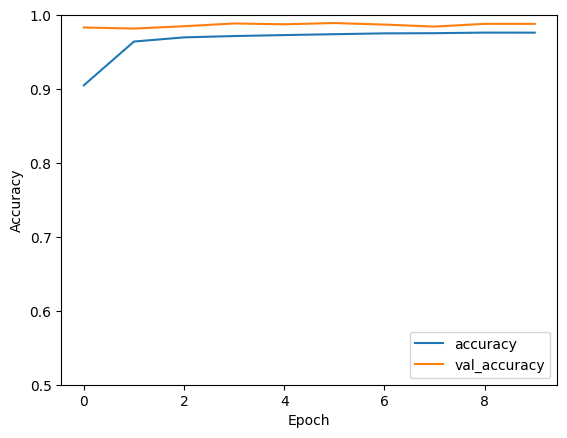

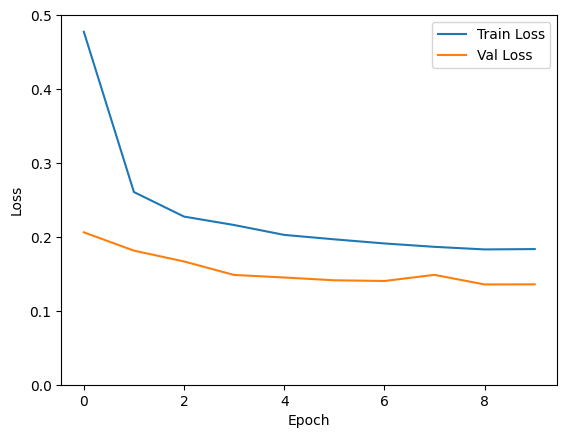

313/313 - 3s - 8ms/step - accuracy: 0.9882 - loss: 0.1356


In [20]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

# **Early Stopping wihtout Dropout**

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Dense(10,activation='softmax'))

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 31ms/step - accuracy: 0.8863 - loss: 0.5126 - val_accuracy: 0.9795 - val_loss: 0.1728
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 32ms/step - accuracy: 0.9794 - loss: 0.1672 - val_accuracy: 0.9849 - val_loss: 0.1264
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 31ms/step - accuracy: 0.9818 - loss: 0.1343 - val_accuracy: 0.9783 - val_loss: 0.1441
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9832 - loss: 0.1254 - val_accuracy: 0.9844 - val_loss: 0.1156
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9831 - loss: 0.1203 - val_accuracy: 0.9861 - val_loss: 0.1068
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9862 - loss: 0.1088 - val_accuracy: 0.9836 - val_loss: 0.1112
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.9860 - loss: 0.1061 - val_accuracy: 0.9863 - val_loss: 0.0996
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9871 -

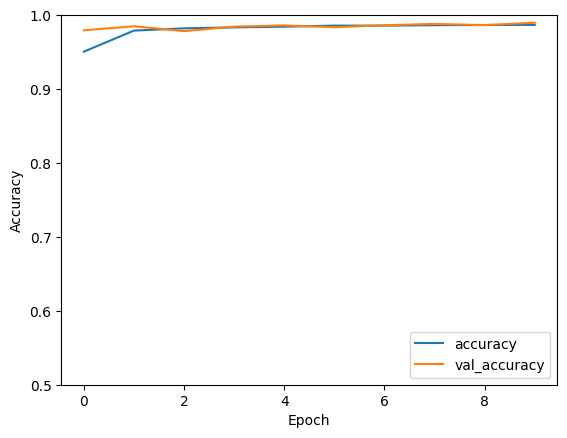

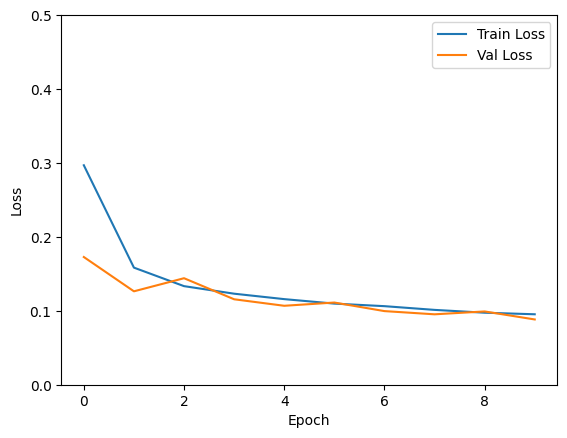

313/313 - 3s - 11ms/step - accuracy: 0.9897 - loss: 0.0883


In [22]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

# **Kernels = 128**

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[early_stopping])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 112s 59ms/step - accuracy: 0.8543 - loss: 0.7055 - val_accuracy: 0.9797 - val_loss: 0.2227
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 59ms/step - accuracy: 0.9672 - loss: 0.2674 - val_accuracy: 0.9858 - val_loss: 0.1837
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 107s 57ms/step - accuracy: 0.9723 - loss: 0.2247 - val_accuracy: 0.9858 - val_loss: 0.1675
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 58ms/step - accuracy: 0.9735 - loss: 0.2080 - val_accuracy: 0.9865 - val_loss: 0.1579
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 57ms/step - accuracy: 0.9755 - loss: 0.1961 - val_accuracy: 0.9888 - val_loss: 0.1418
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 107s 57ms/step - accuracy: 0.9760 - loss: 0.1843 - val_accuracy: 0.9898 - val_loss: 0.1340
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 109s 58ms/step - accuracy: 0.9751 - loss: 0.1813 - val_accuracy: 0.9886 - val_loss: 0.1293
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 141s 57ms/step - accuracy: 0.9780 - lo

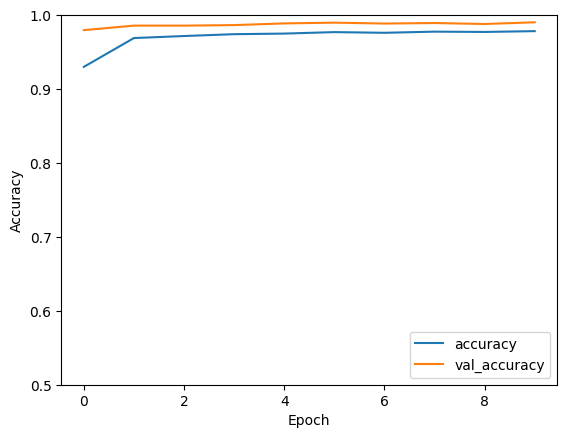

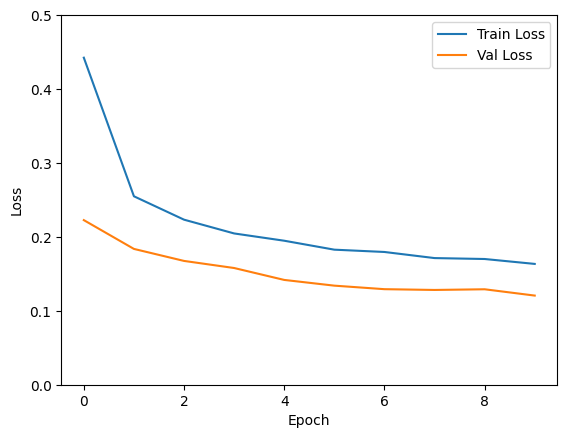

313/313 - 4s - 11ms/step - accuracy: 0.9903 - loss: 0.1206


In [24]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

# **kernel to 5X5**

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential()
model.add(layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (5, 5), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
# Removed the second MaxPooling2D layer to accommodate larger kernels
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (5, 5), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[early_stopping])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 93s 47ms/step - accuracy: 0.8402 - loss: 0.6912 - val_accuracy: 0.9861 - val_loss: 0.1988
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 48ms/step - accuracy: 0.9706 - loss: 0.2447 - val_accuracy: 0.9870 - val_loss: 0.1628
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 48ms/step - accuracy: 0.9756 - loss: 0.2065 - val_accuracy: 0.9886 - val_loss: 0.1493
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 49ms/step - accuracy: 0.9790 - loss: 0.1871 - val_accuracy: 0.9898 - val_loss: 0.1354
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 91s 48ms/step - accuracy: 0.9792 - loss: 0.1732 - val_accuracy: 0.9878 - val_loss: 0.1336
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 92s 49ms/step - accuracy: 0.9783 - loss: 0.1726 - val_accuracy: 0.9905 - val_loss: 0.1174
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 90s 48ms/step - accuracy: 0.9805 - loss: 0.1589 - val_accuracy: 0.9830 - val_loss: 0.1411
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 90s 48ms/step - accuracy: 0.9811 - loss: 0.1

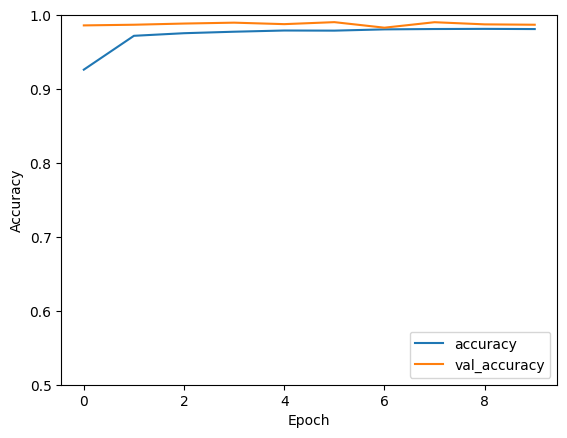

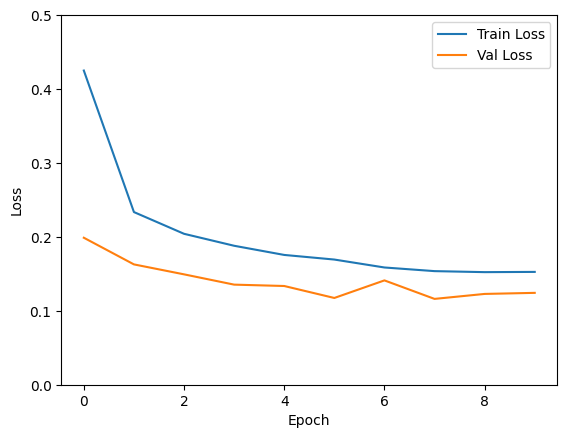

313/313 - 5s - 15ms/step - accuracy: 0.9904 - loss: 0.1161


In [28]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

# **kernel to 7x7**

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential()
model.add(layers.Conv2D(32, (7, 7), activation='relu', input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001), padding='same'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (7, 7), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), padding='same'))
# Removed the second MaxPooling2D layer to accommodate larger kernels
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (7, 7), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001), padding='same'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.8417 - loss: 0.6772 - val_accuracy: 0.9851 - val_loss: 0.2144
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9627 - loss: 0.2914 - val_accuracy: 0.9870 - val_loss: 0.1837
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9700 - loss: 0.2476 - val_accuracy: 0.9885 - val_loss: 0.1681
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9709 - loss: 0.2301 - val_accuracy: 0.9887 - val_loss: 0.1597
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9738 - loss: 0.2180 - val_accuracy: 0.9875 - val_loss: 0.1617
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9748 - loss: 0.2130 - val_accuracy: 0.9884 - val_loss: 0.1499
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9765 - loss: 0.1983 - val_accuracy: 0.9868 - val_loss: 0.1479
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9761 - loss: 0.1969 - val

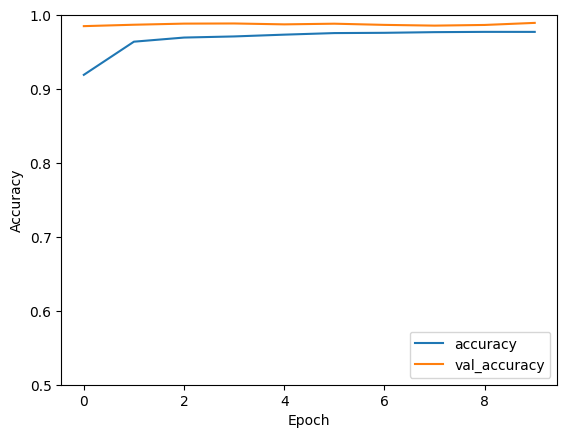

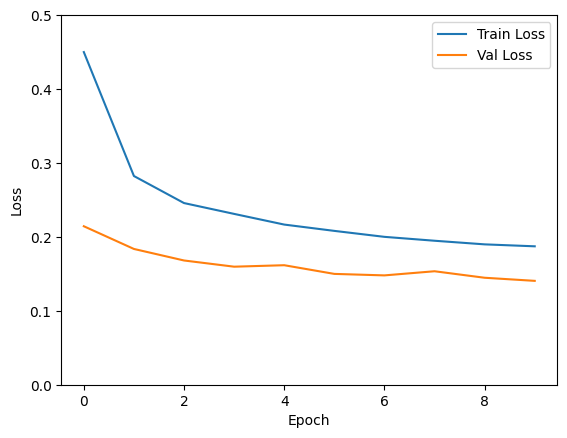

313/313 - 1s - 3ms/step - accuracy: 0.9895 - loss: 0.1405


In [10]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)

# **Average Pooling**

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28,28,1), kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.AveragePooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.AveragePooling2D((2, 2)))
model.add(layers.Dropout(0.25))
model.add(layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

# Early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test), callbacks=[early_stopping])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.7759 - loss: 0.8589 - val_accuracy: 0.9694 - val_loss: 0.2544
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9503 - loss: 0.3296 - val_accuracy: 0.9802 - val_loss: 0.2048
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9606 - loss: 0.2739 - val_accuracy: 0.9786 - val_loss: 0.1979
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9638 - loss: 0.2587 - val_accuracy: 0.9839 - val_loss: 0.1771
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9657 - loss: 0.2425 - val_accuracy: 0.9830 - val_loss: 0.1751
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9675 - loss: 0.2391 - val_accuracy: 0.9824 - val_loss: 0.1781
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9693 - loss: 0.2264 - val_accuracy: 0.9850 - val_loss: 0.1636
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9710 - loss: 0.2191 

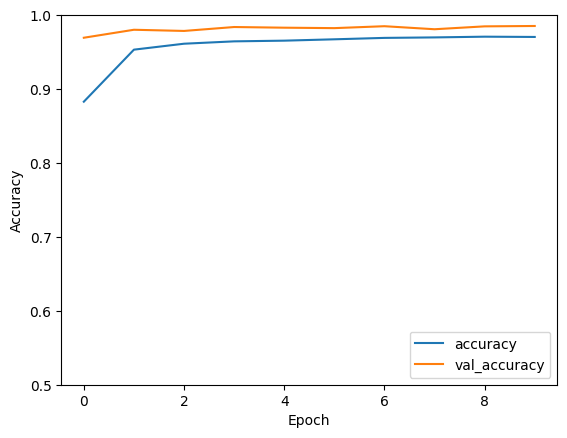

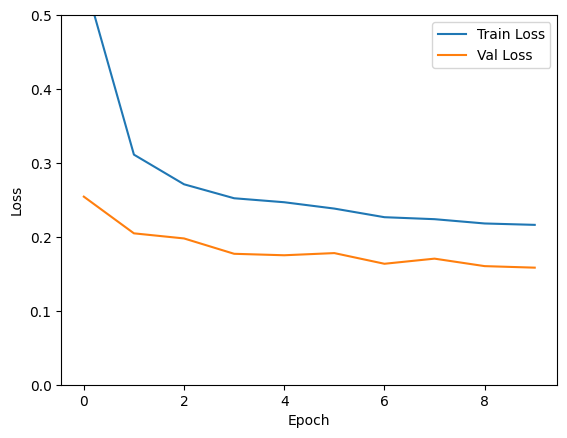

313/313 - 1s - 2ms/step - accuracy: 0.9853 - loss: 0.1584


In [12]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.show()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 0.5])
plt.legend(loc='upper right')
plt.show()

test_loss, test_acc = model.evaluate(x_test,y_test, verbose=2)